# Sequences

In [1]:
# Imports 
# ==========

import matplotlib.pyplot as plt
import torch
from torch import nn

%matplotlib inline

When making a model around the data we need to make sure that we create the model that takes a certain number of inputs and then gives us certain outputs. But what if we dont have a input stream of fixed length then we need to design the models according to this. 

Here is where RNN comes in picture where you have a certain unfixed sequence of inputs (timed) that can be a trading data or and event prediction in weather models. 

General statement to predict is : 

$P(x_t | x_{t-1}, \dots , x_1)$

we just want to know the Probability of happening of $x_t$ given certain events have already happend. Easy way is to calculate the **Conditional Expectation** and go with it other better way is to actually observe the patterns and behaviours in the data and then get a conditional probability of that event. 

Also we might not even have to look out to all of the historical data in order to actually predict we can just look at the past $\tau$ events to predict the next event. 

Also we can deveop models that maintains some summary $h_t$ of the past observations and at the same time update the $h_t$ in addition to prediction $\hat{x_t}$. This leads to model which not only estimate $x_t$ with $\hat{x_t} = P(x_t | h_t)$ but also updates of the form $h_t = g(h_{t-1}, x_{t-1})$. Since here we never observe $h_t$ these models are called **Latent Auto Regressive Models**

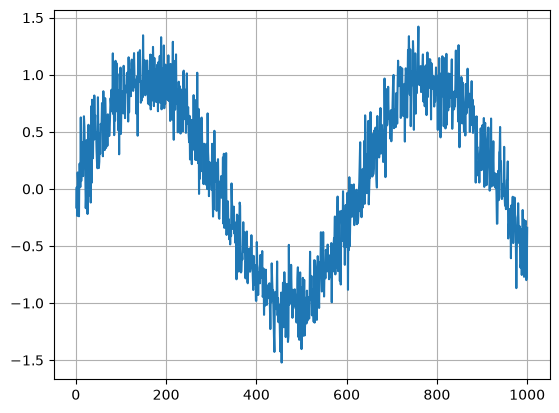

In [2]:
# Data Gen
# =================

def synth_data_gen(samples=1000):
    time = torch.arange(1, samples + 1, dtype=torch.float32)
    # x compoenent = sin value + random noise
    x = torch.sin(0.01 * time) + torch.randn(samples) * 0.2
    return time, x

time, x = synth_data_gen()
plt.plot(
    time, x
)
plt.grid()

In [3]:
# Model 
# ========

class LinReg(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.net(x)

In [4]:
# Data Loading 
# ===============

def get_data(tau=4, num_train=60, samples=1000):
    """
    Get train, test data split from synth_data_gen

    We are lining up the values : 

    [1, 2, 3, 4] --> 5,
    [2, 3, 4, 5] --> 6, 
    ....
    ...
    ..

    inputs: 

    tau : factor regarding how far in the past to 
    num_train : number of training samples (percentage)
    samples : number of synth data samples

    outputs:

    (time, x) : the raw series the split was built from
    train data, test data
    """

    time, x = synth_data_gen(samples)
    features = [x[i : samples - tau + i] for i in range(tau)]
    features = torch.stack(features, 1)
    labels = x[tau:].reshape((-1, 1))
    split_idx = int(len(features) * num_train / 100)
    train = (features[:split_idx], labels[:split_idx])
    test = (features[split_idx:], labels[split_idx:])
    return (time, x), train, test

In [5]:
_, train_split, test_split = get_data()
print(train_split[0][0], " | ", train_split[1][0])

tensor([-0.1823,  0.0402,  0.0542, -0.1386])  |  tensor([0.0701])


In [6]:
# Train loop 
# =====================

def train(model, optimiser, loss_fn, epochs, train_data):
    features, labels = train_data
    for epoch in range(epochs):
        total_loss = 0.0
        for feature, label in zip(features, labels):
            prediction = model(feature)
            loss = loss_fn(prediction, label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            total_loss += loss.item()
        print(f">>> epoch: {epoch}, loss (training): {total_loss / len(features)}")


In [7]:
# Train Params
# ==============

EPOCHS = 5
learning_rate = 0.01
TAU = 4
train_percentage = 60
samples = 1000

# rebind time/x to the series the split was actually built from
(time, x), train_data, test_data = get_data(
    tau=TAU,
    num_train=train_percentage,
    samples=samples
)

print(train_data[0])

model = LinReg(TAU)
optimiser = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)
loss_fn = nn.MSELoss()

tensor([[ 0.1254, -0.0932, -0.2071,  0.0128],
        [-0.0932, -0.2071,  0.0128, -0.0835],
        [-0.2071,  0.0128, -0.0835,  0.0645],
        ...,
        [-0.4631, -0.2300, -0.4417, -0.1881],
        [-0.2300, -0.4417, -0.1881, -0.0721],
        [-0.4417, -0.1881, -0.0721, -0.1199]])


In [8]:
train(model, optimiser, loss_fn, EPOCHS, train_data)

>>> epoch: 0, loss (training): 0.07781310130946063
>>> epoch: 1, loss (training): 0.052548287972860985
>>> epoch: 2, loss (training): 0.04818352411802148
>>> epoch: 3, loss (training): 0.047906252176329156
>>> epoch: 4, loss (training): 0.04783947546897713


In [9]:
model.eval()
with torch.no_grad():
    one_step_predictions = model(test_data[0]).squeeze(-1).numpy()

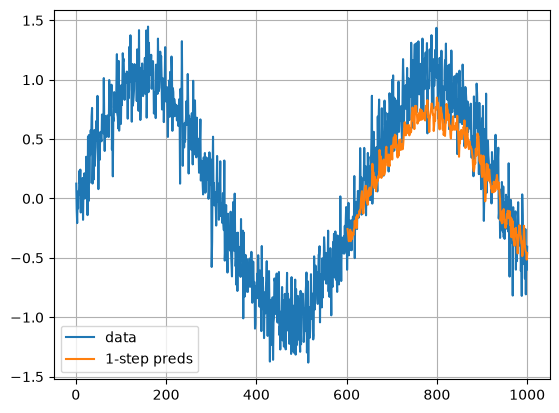

In [10]:
# prediction j is for x[TAU + split_idx + j], so the test predictions
# start TAU + len(train) steps into the series
pred_time = time[TAU + len(train_data[0]):]

plt.plot(time, x, label="data")
plt.plot(pred_time, one_step_predictions, label="1-step preds")
plt.legend()
plt.grid()